## 'Ford 엔진 데이터 예지보전 파이프라인' - 로지스틱 회귀
### [Cell 1] 라이브러리 설정, 데이터 로드 및 분할 (단계 1)
로우 데이터(Raw Data)를 메모리에 적재하고, 정상/비정상 클래스 비율을 유지하며 시스템 검증용 데이터셋으로 분리합니다.

In [5]:
from pathlib import Path
import itertools
import random
from time import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.collections import EllipseCollection
from scipy.io.arff import loadarff
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf

# 1. 시스템 루트 마커 기반 동적 탐색 함수
def get_project_root() -> Path:
    current_path = Path.cwd()
    for parent in [current_path, *current_path.parents]:
        if (parent / "PHM_Ford_Vibration.md").exists():
            return parent
    raise FileNotFoundError("시스템 루트 마커(PHM_Ford_Vibration.md)를 찾을 수 없습니다. 실행 환경을 확인하세요.")

# 2. 주요 시스템 디렉토리 논리적 매핑
ROOT_DIR = get_project_root()
DATA_DIR = ROOT_DIR / "dataset"
SAVE_DIR = ROOT_DIR / "Result"
SAVE_DIR.mkdir(parents=True, exist_ok=True) # 폴더가 없으면 자동 생성

print(f"동적 탐색된 시스템 루트: {ROOT_DIR}")
print(f"데이터 탐색 경로: {DATA_DIR}")
print(f"결과물 저장 경로: {SAVE_DIR}")

# 3. 데이터 로드 및 분할 구조 설계
train_fn = DATA_DIR / "FordA_TRAIN.arff"
test_fn = DATA_DIR / "FordA_TEST.arff"

def read_ariff(path):
    raw_data, meta = loadarff(path)
    cols = [x for x in meta]
    data2d = np.zeros([raw_data.shape[0],len(cols)])
    
    for i, col in zip(range(len(cols)),cols):
        data2d[:,i]=raw_data[col]
    return data2d

train = read_ariff(train_fn)
test = read_ariff(test_fn)

x_train_temp = train[:,:-1]
y_train_temp = train[:, -1] 
x_test = test[:, :-1]
y_test = test[:, -1] 

normal_x=x_train_temp[y_train_temp==1] 
abnormal_x=x_train_temp[y_train_temp==-1] 
normal_y=y_train_temp[y_train_temp==1] 
abnormal_y=y_train_temp[y_train_temp==-1] 

ind_x_normal = int(normal_x.shape[0]*0.8) 
ind_y_normal = int(normal_y.shape[0]*0.8) 
ind_x_abnormal = int(abnormal_x.shape[0]*0.8) 
ind_y_abnormal = int(abnormal_y.shape[0]*0.8) 

x_train = np.concatenate((normal_x[:ind_x_normal], abnormal_x[:ind_x_abnormal]), axis=0)
x_valid = np.concatenate((normal_x[ind_x_normal:], abnormal_x[ind_x_abnormal:]), axis=0)
y_train = np.concatenate((normal_y[:ind_y_normal], abnormal_y[:ind_y_abnormal]), axis=0)
y_valid = np.concatenate((normal_y[ind_y_normal:], abnormal_y[ind_y_abnormal:]), axis=0)

동적 탐색된 시스템 루트: /Users/alohyomora/dev/github/Hyundai-Autoever-Mobility-SW---SmartFactory-Study/motor_vibration_anomaly_detection
데이터 탐색 경로: /Users/alohyomora/dev/github/Hyundai-Autoever-Mobility-SW---SmartFactory-Study/motor_vibration_anomaly_detection/dataset
결과물 저장 경로: /Users/alohyomora/dev/github/Hyundai-Autoever-Mobility-SW---SmartFactory-Study/motor_vibration_anomaly_detection/Result


### [Cell 2] 데이터 구조적 결함 및 특성 시각적 디버깅 (단계 2)
모델이 무조건 '정상'으로 편향되는 실패 시나리오를 막기 위해 클래스 불균형을 점검하고, 시계열 노이즈 패턴을 플롯으로 확인합니다.

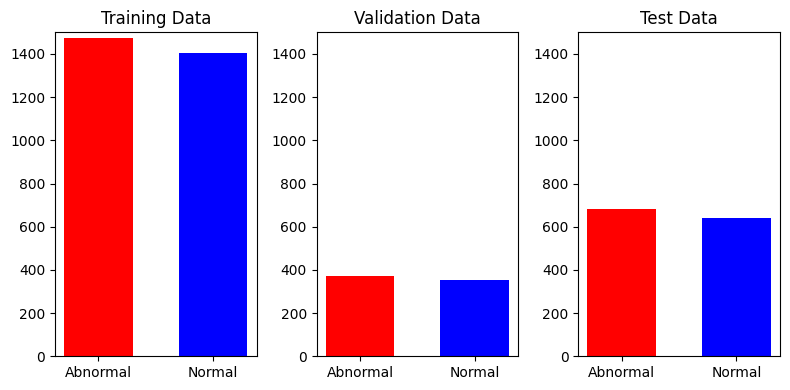

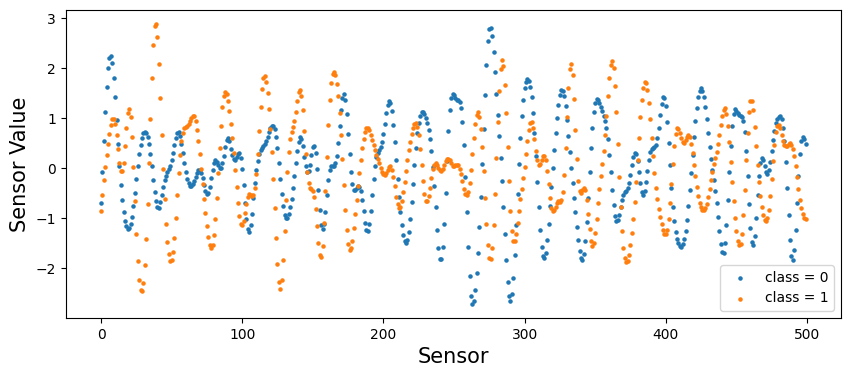

In [6]:
# 1. Class 종류 확인 및 불균형 확인
classes = np.unique(np.concatenate((y_train, y_test), axis=0)) 
x = np.arange(len(classes))  
labels = ["Abnormal", "Normal"]  

values_train = [(y_train == i).sum() for i in classes]  
values_valid = [(y_valid == i).sum() for i in classes]  
values_test = [(y_test == i).sum() for i in classes]  

plt.figure(figsize=(8,4))  
plt.subplot(1,3,1)  
plt.title("Training Data")  
plt.bar(x, values_train, width=0.6, color=["red", "blue"])  
plt.ylim([0, 1500])
plt.xticks(x, labels)  

plt.subplot(1,3,2)  
plt.title("Validation Data")
plt.bar(x, values_valid, width=0.6, color=["red", "blue"])  
plt.ylim([0, 1500])
plt.xticks(x, labels)

plt.subplot(1,3,3)  
plt.title("Test Data")
plt.bar(x, values_test, width=0.6, color=["red", "blue"])  
plt.ylim([0, 1500])
plt.xticks(x, labels)

plt.tight_layout()  
plt.savefig(SAVE_DIR / 'data_imbalance.png', dpi=100, bbox_inches='tight')  
plt.show()

# 2. 특정 시간에서의 시계열 샘플 플롯 (정상/비정상 비교)
labels_unique = np.unique(np.concatenate((y_train, y_test), axis=0))
plt.figure(figsize = (10, 4))
for c in labels_unique:
    c_x_train = x_train[y_train == c]
    if c == -1: c = c + 1  
    time_t = random.randint(0, c_x_train.shape[0])  
    plt.scatter(range(0, 500), c_x_train[time_t], label="class = " + str(int(c)), marker='o', s=5)
plt.legend(loc="lower right")
plt.xlabel("Sensor", fontsize=15)
plt.ylabel("Sensor Value", fontsize=15)
plt.savefig(SAVE_DIR / 'ford_data_ts_sample1.png', dpi=100, bbox_inches='tight')
plt.show()

### [Cell 3] 센서 간 종속성 파악 (단계 3)
500개 변수의 다중 공선성 및 상관도를 도출합니다.

/var/folders/3r/jx5_g21j0fb9kcf0k01sdx2h0000gn/T/ipykernel_36665/2454798279.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet', 31)


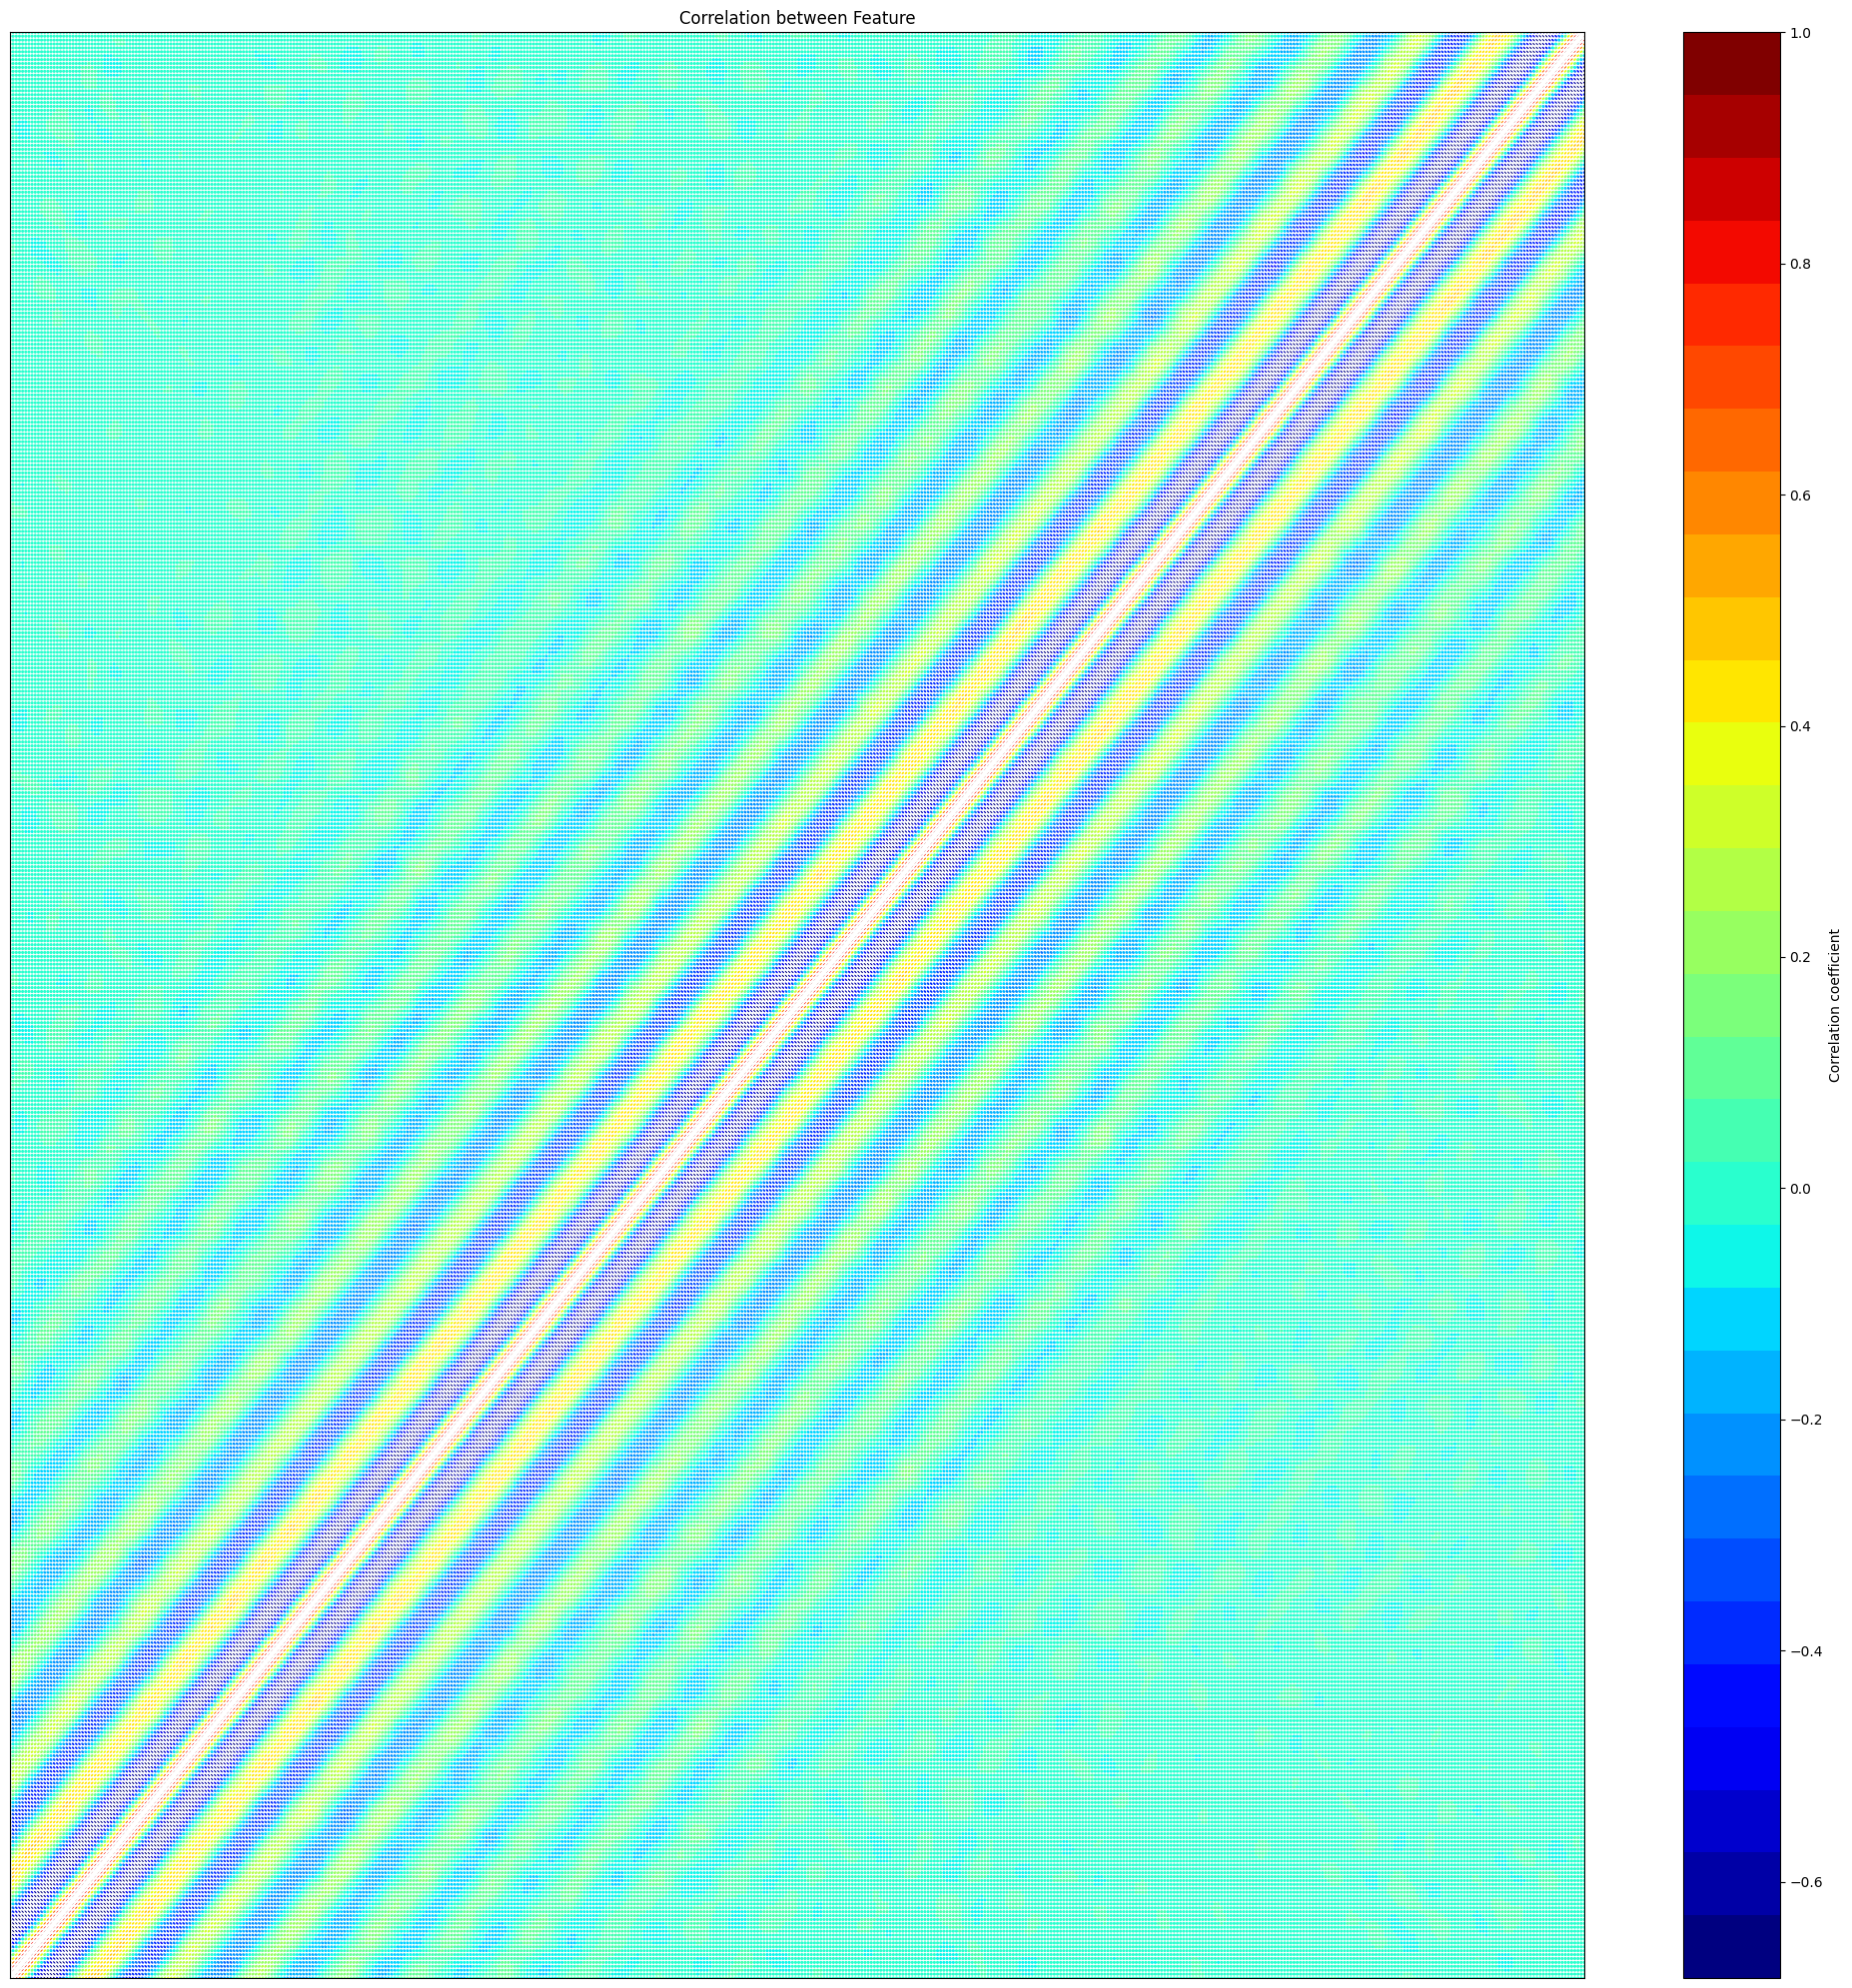

In [7]:
df = pd.DataFrame(data = x_train,
                  columns = ["sensor_{}".format(label+1) for label in range(x_train.shape[1])])
data = df.corr()

def plot_corr_ellipses(data, ax = None, **kwargs):
    M = np.array(data)
    if not M.ndim == 2:
        raise ValueError('data must be a 2D array')
    if ax is None:
        fig, ax = plt.subplots(1, 1, subplot_kw={'aspect':'equal'})
        ax.set_xlim(-0.5, M.shape[1] - 0.5)
        ax.set_ylim(-0.5, M.shape[0] - 0.5)
        
    xy = np.indices(M.shape)[::-1].reshape(2, -1).T
    w = np.ones_like(M).ravel()
    h = 1 - np.abs(M).ravel()
    a = 45 * np.sign(M).ravel()
    
    ec = EllipseCollection(widths=w, heights=h, angles=a, units='x', offsets=xy,
                           transOffset=ax.transData, array=M.ravel(), **kwargs)
    ax.add_collection(ec)
    
    if isinstance(data, pd.DataFrame):
        ax.set_xticks(np.arange(M.shape[1]))
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticks(np.arange(M.shape[0]))
        ax.set_yticklabels(data.index)
    return ec

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
cmap = cm.get_cmap('jet', 31)
m = plot_corr_ellipses(data, ax=ax, cmap=cmap)
cb = fig.colorbar(m)
cb.set_label('Correlation coefficient')
plt.title('Correlation between Feature')
ax.axes.xaxis.set_visible(False)
ax.axes.yaxis.set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'corr.png', dpi=100, bbox_inches='tight') 
plt.show()

### [Cell 4] 스케일링 및 텐서 변환 (단계 4)
시스템에 노이즈를 유발하는 분산을 통제하고, 다차원 연산을 위한 텐서 변환을 수행합니다.

In [9]:
# Standard Scaler 적용
stder = StandardScaler()
stder.fit(x_train)
x_train = stder.transform(x_train)
x_valid = stder.transform(x_valid)

# 모델의 입력 규격을 맞추기 위해 채널 1개 차원을 확장 (3D Tensor 변환)
x_train_exp = np.expand_dims(x_train, -1) 
x_valid_exp = np.expand_dims(x_valid, -1) 
x_test_exp = np.expand_dims(x_test, -1) 

# 종속변수(y)를 양의 값으로 변경
y_train[y_train== -1] =0
y_valid[y_valid==-1] =0
y_test[y_test == -1] =0

print("전처리 완료 - 데이터 불균형 점검, 시계열 샘플 시각화, 상관관계 분석, 스케일링, 텐서 변환까지 모두 완료되었습니다.")

전처리 완료 - 데이터 불균형 점검, 시계열 샘플 시각화, 상관관계 분석, 스케일링, 텐서 변환까지 모두 완료되었습니다.


## 로지스틱 회귀(Logistic Regression) 모델 구축 및 평가
로지스틱회귀(Logistic Regression)이란 데이터가 어떤 카테고리에 속할지를 0과 1사이의 연속적인 확률로 예측하는 회귀알고리즘이다.

### [Cell 5] Scikit-learn 라이브러리 - 로지스틱 회귀 모델 불러오기

In [20]:
# 로지스틱 회귀 모델 불러오기 코드
from sklearn.linear_model import LogisticRegression

clf_lr_1 = LogisticRegression(penalty='l2', tol=0.0001, C=1, fit_intercept=True,
							  intercept_scaling=1, random_state=2, solver='liblinear',
							  max_iter=1000, verbose=0)

### [Cell 6] 학습 - 로지스틱 회귀(Logistic Regression)

In [21]:
# 로지스틱 회귀 모델 학습을 위한 학습용/테스트용 데이터 재구성
x_train_lr = np.concatenate((x_train, x_valid), axis=0) # 로지스틱 회귀 학습용 데이터
y_train_lr = np.concatenate((y_train, y_valid), axis=0) # 로지스틱 회귀 테스트용 데이터

# 방법 1) Scikit-learn 로지스틱 회귀 모델 학습
# 단계 5의 (1) scikit-learn Logistic Regression 모델 구축에서, 모델 인스턴스 이름 clf_lr_1
clf_lr_1.fit(x_train_lr, y_train_lr)

# 방법 2) numpy로 구현한 로지스틱 회귀 모델 학습

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,2
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'
